# Early Diabetes Prediction Using Machine Learning Algorithms

## Problem Statement:Diabetes is a chronic disease that affects millions of people worldwide, and early detection is essential to prevent serious health complications. Healthcare professionals often need to evaluate multiple medical and demographic factors, making timely diagnosis challenging. This project aims to develop a machine learning model that predicts whether a patient is diabetic (positive) or non-diabetic (negative) using features such as age, gender, Body Mass Index (BMI), hypertension, heart disease, smoking history, HbA1c level, and blood glucose level. The target variable is Diabetes, which classifies patients into diabetic or non-diabetic categories. An accurate predictive model can assist healthcare professionals in early risk identification, support timely clinical decision-making, and enable personalized treatment and preventive care.

In [1]:
import pandas as pd
import numpy as np
DiabetesPredictionData=pd.read_csv("C:/Users/abrau/ML Projects/My ML Projects/Classification Projects/Diabetes/diabetes_prediction_dataset.csv",
                            encoding='latin')
print('Data Before deleting duplicate values:',DiabetesPredictionData.shape)  
DiabetesPredictionData.drop_duplicates(inplace=True)
print('Data After:deleting duplicate values',DiabetesPredictionData.shape)
pd.set_option('display.max_rows',None) 
pd.set_option('display.max_columns',None)  
DiabetesPredictionData.head(10)

Data Before deleting duplicate values: (100000, 9)
Data After:deleting duplicate values (96146, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


### Target Variable:diabetes

## Exploratory Data Analysis

<Axes: xlabel='diabetes'>

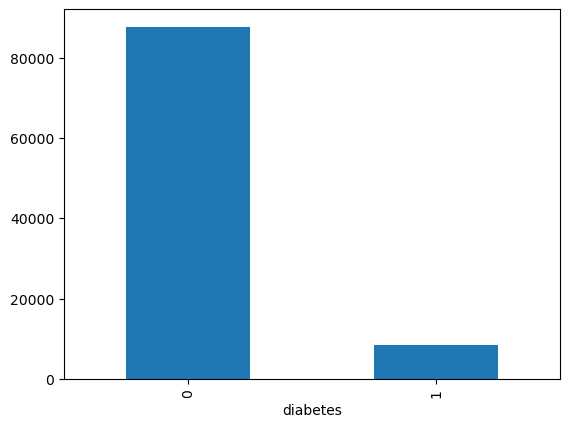

In [2]:
DiabetesPredictionData.groupby('diabetes').size().plot(kind='bar')

In [14]:
DiabetesPredictionData.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [15]:
DiabetesPredictionData.nunique()

gender                    3
age                     102
hypertension              2
heart_disease             2
smoking_history           6
bmi                    4247
HbA1c_level              18
blood_glucose_level      18
diabetes                  2
dtype: int64

### CategoricalCols=['gender','hypertension', 'heart_disease', 'smoking_history','diabetes']
### ContinousCols=[ 'age','bmi','HbA1c_level', 'blood_glucose_level']

In [25]:
DiabetesPredictionData.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


## Uni Variate Analysis by Bar Charts

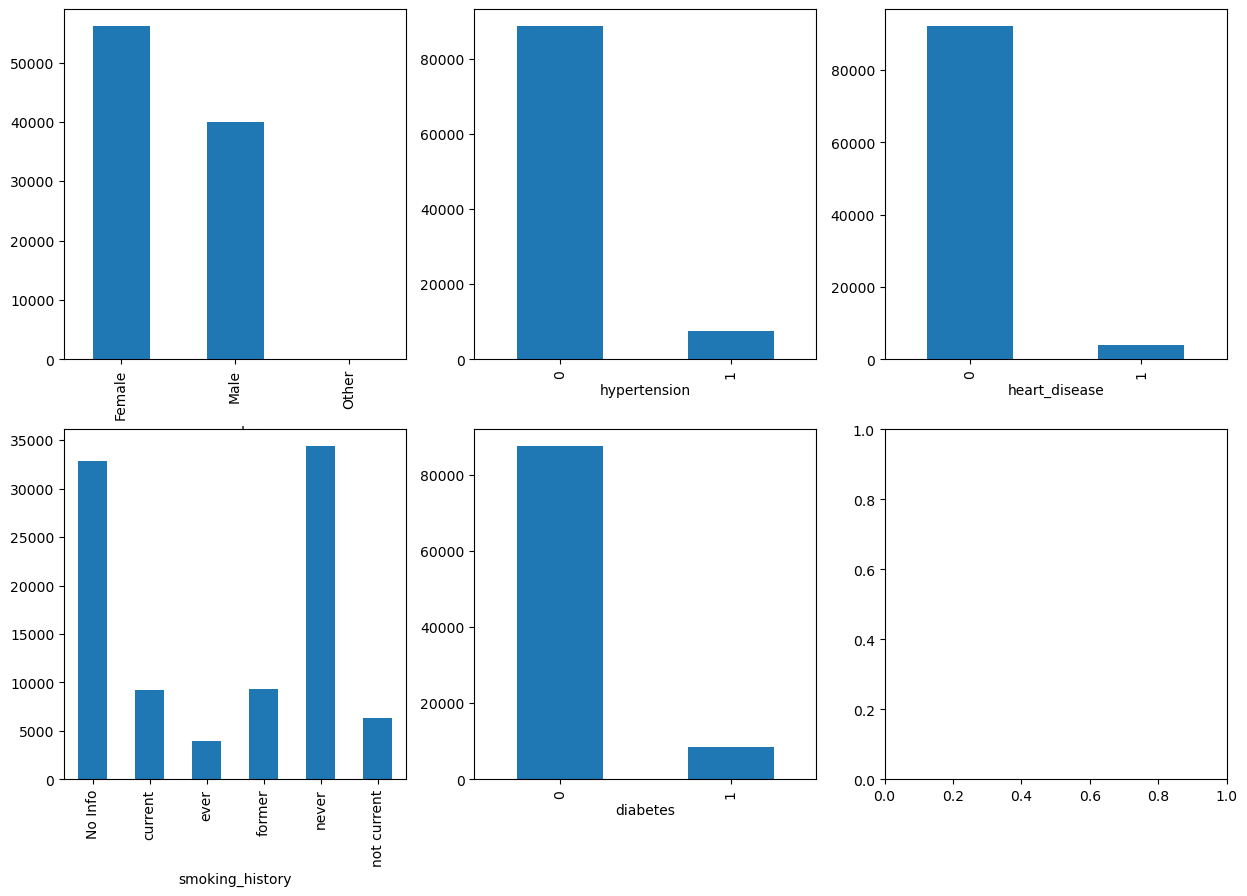

In [30]:
CategoricalCols=['gender','hypertension', 'heart_disease', 'smoking_history','diabetes']
import matplotlib.pyplot as plt
fig, subplots=plt.subplots(2,3,figsize=(15,10))
subplots=subplots.flatten()
for cols , no_of_cols in zip(CategoricalCols,range(len(CategoricalCols))):
    DiabetesPredictionData.groupby(cols).size().plot(kind='bar',ax=subplots[no_of_cols])

In [32]:
DiabetesPredictionData.groupby('gender').size()

gender
Female    56161
Male      39967
Other        18
dtype: int64

### Imbalance treatment

In [34]:
DiabetesPredictionData=DiabetesPredictionData[DiabetesPredictionData['gender']!='Other']

In [35]:
DiabetesPredictionData.shape

(96128, 9)

## Uni Variate Analysis by Histogram

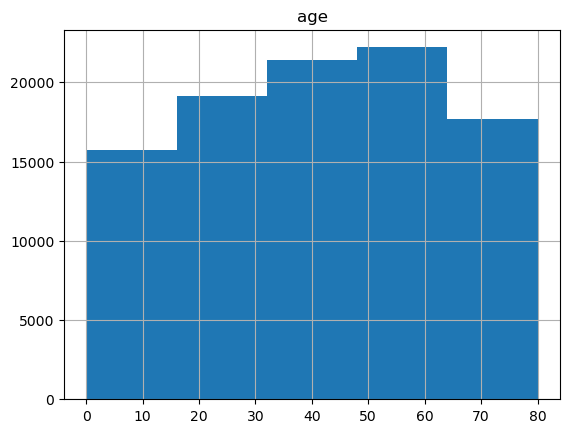

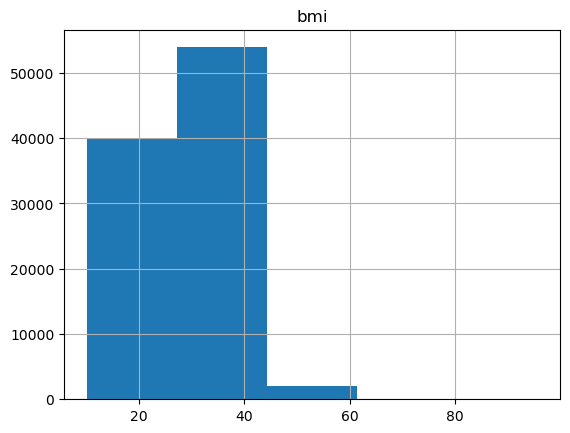

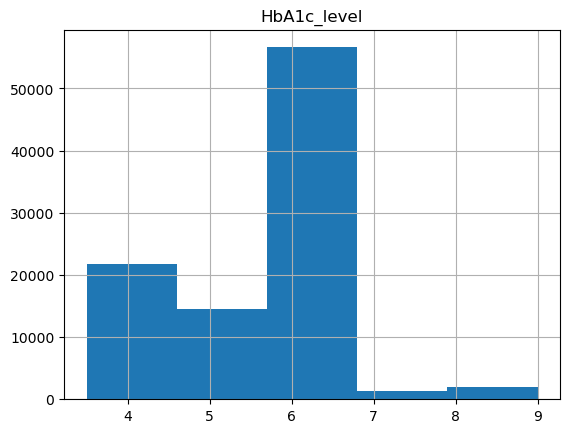

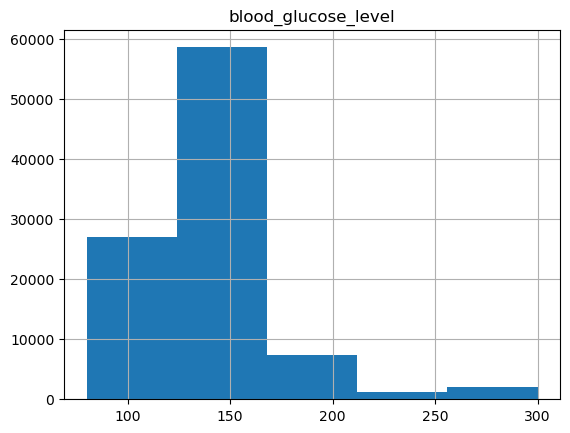

In [39]:
ContinousCols=[ 'age','bmi','HbA1c_level', 'blood_glucose_level']
for cols in ContinousCols:
    DiabetesPredictionData.hist(cols,bins=5)

## No Need of Outlier Treatment

### No need of missing value treatment

In [40]:
DiabetesPredictionData.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

## Continous Vs Categorical Bivariate Analysis by Box Plots

In [41]:
DiabetesPredictionData.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

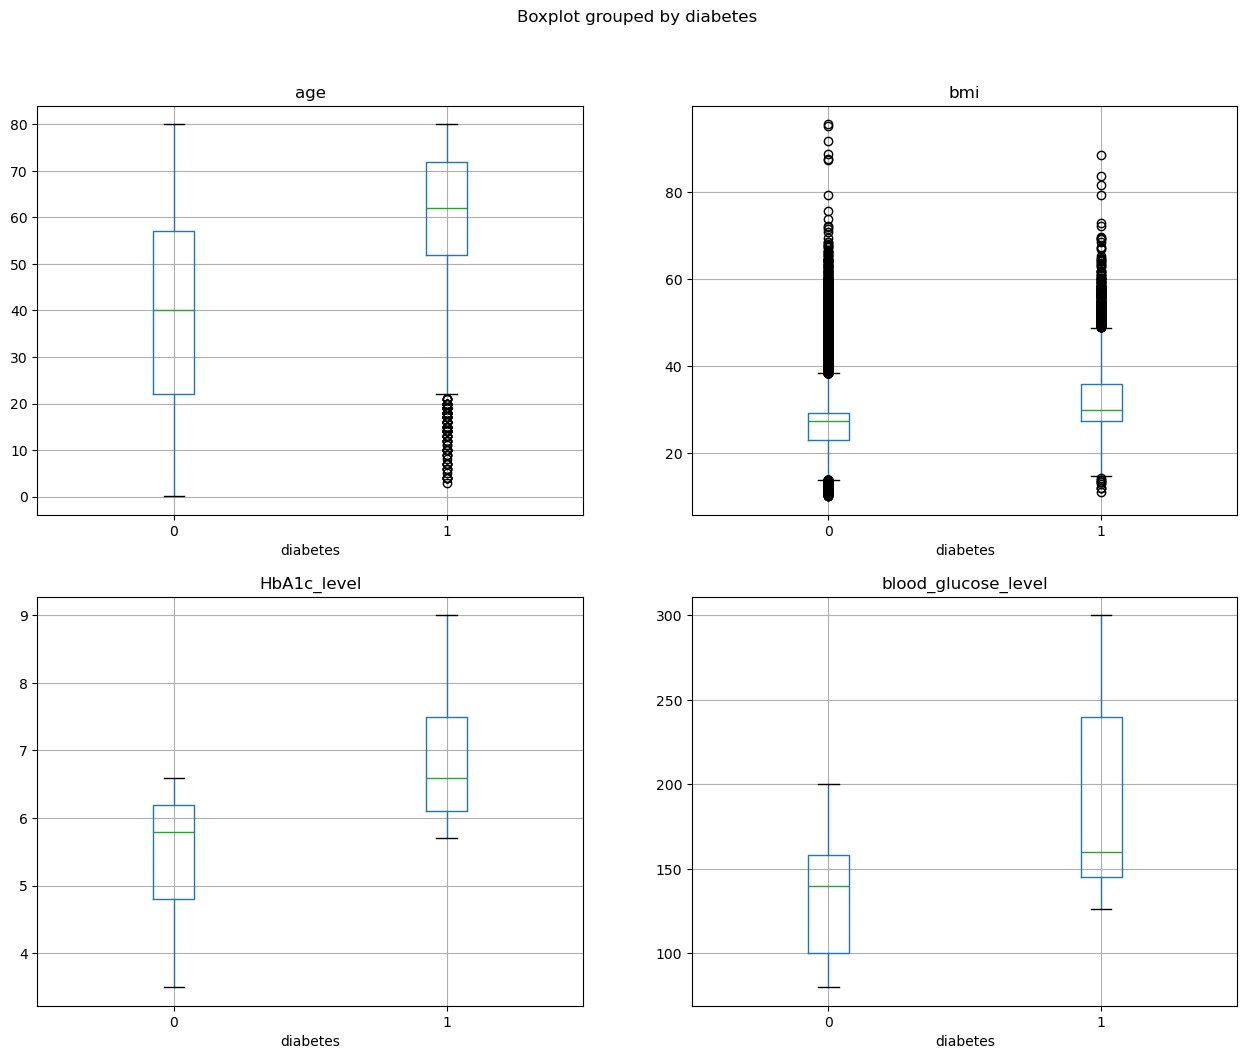

In [44]:
ContinousCols=[ 'age','bmi','HbA1c_level', 'blood_glucose_level']
import matplotlib.pyplot as plt
fig,subplots=plt.subplots(2,2,figsize=(15,12))
subplots=subplots.flatten()
for cols, no_of_cols in zip(ContinousCols,range(len(ContinousCols))):
    DiabetesPredictionData.boxplot(column=cols,by='diabetes',vert=True,ax=subplots[no_of_cols])

## Statistical Feature Selection by Anova Function

In [46]:
def function_Anova(Data, contnousCols, targetVariable):
    ContinousCols=[ 'age','bmi','HbA1c_level', 'blood_glucose_level']
    SelectedPredictors=[]
    from scipy.stats import f_oneway
    for cols in ContinousCols:
        CategoricalGroupLists=Data.groupby(targetVariable)[cols].apply(list)
        AnovaResults=f_oneway(*CategoricalGroupLists)
        if AnovaResults[0]<0.05:
            print('Diabetes is correlated with ', cols,'and P value is:', AnovaResults[0])
            SelectedPredictors.append(cols)
        else:
            print('Diabetes is not correlated with ', cols,'and P value is:', AnovaResults[0])
    return SelectedPredictors

function_Anova(Data=DiabetesPredictionData, contnousCols=[ 'age','bmi','HbA1c_level', 'blood_glucose_level'], targetVariable='diabetes') 

Diabetes is not correlated with  age and P value is: 7255.465132960609
Diabetes is not correlated with  bmi and P value is: 4656.561451005961
Diabetes is not correlated with  HbA1c_level and P value is: 19022.304383161074
Diabetes is not correlated with  blood_glucose_level and P value is: 21113.25029683189


[]

## Categorical Vs Categorical Bivariate Analysis by Grouped Bar Charts

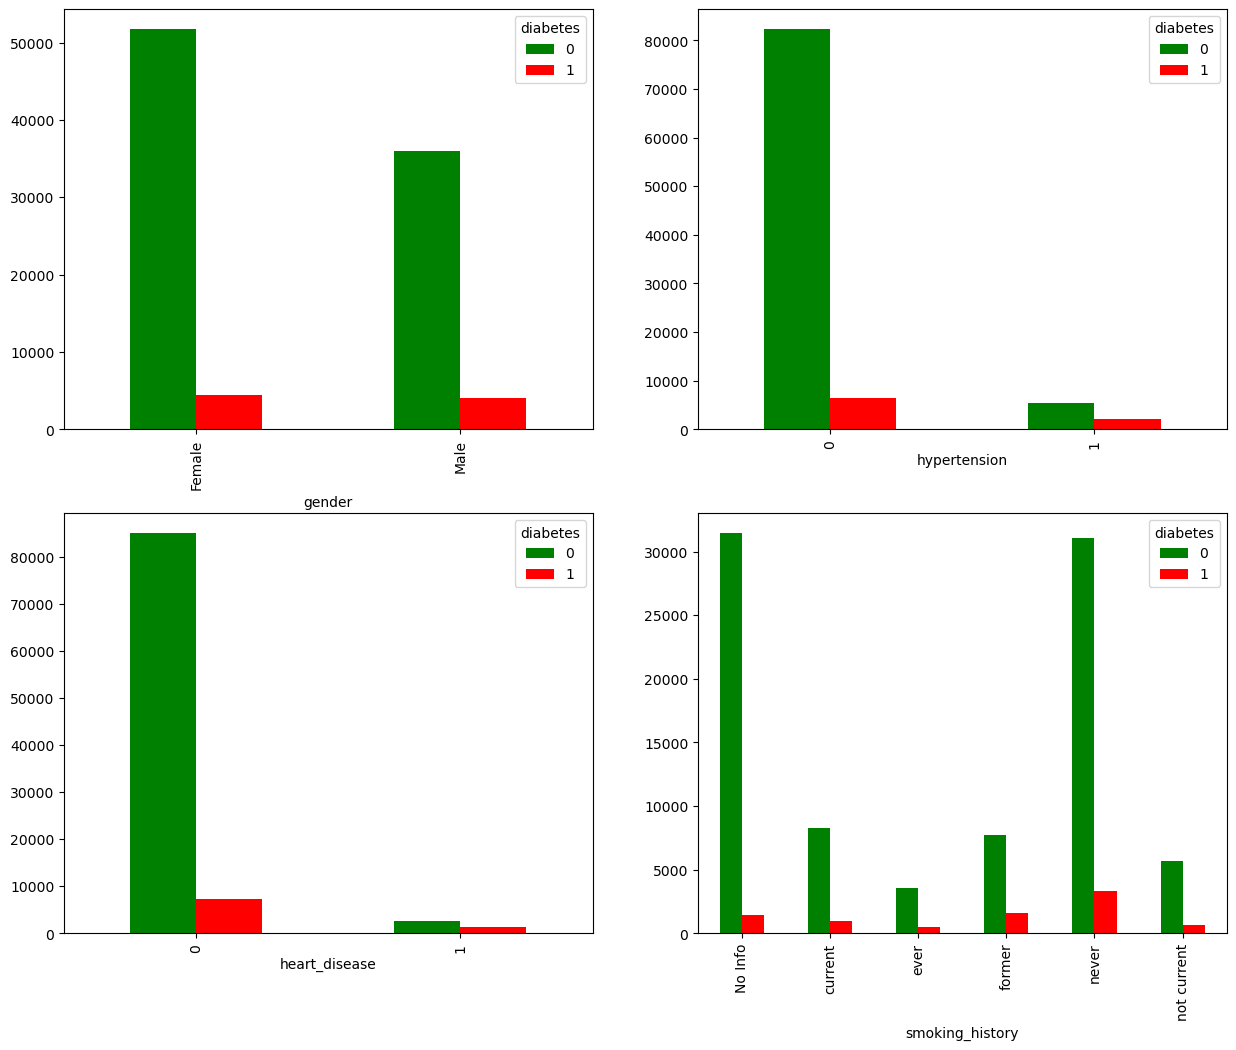

In [50]:
CategoricalCols=['gender','hypertension', 'heart_disease', 'smoking_history']
import matplotlib.pyplot as plt
fig,subplots=plt.subplots(2,2,figsize=(15,12))
subplots=subplots.flatten()
for cols, no_of_cols in zip(CategoricalCols,range(len(CategoricalCols))):
    crosstabresults=pd.crosstab(columns=DiabetesPredictionData['diabetes'],index=DiabetesPredictionData[cols])
    crosstabresults.plot.bar(color=['green','red'],ax=subplots[no_of_cols])


## Statistical Feature Selection by Chi2 Function

In [51]:
CategoricalCols=['gender','hypertension', 'heart_disease', 'smoking_history']
SelectedPredictors=[]
from  scipy.stats  import chi2_contingency
for  cols in CategoricalCols:
    crosstabresults=pd.crosstab(columns=DiabetesPredictionData['diabetes'],index=DiabetesPredictionData[cols]) 
    chi2_results=chi2_contingency(crosstabresults) 
    if chi2_results[1]<0.05:
        print(cols,' is correlated with diabetes and p value is:',chi2_results[1])
        SelectedPredictors.append(cols)
    else:
        print(cols,' is not correlated with diabetes and p value is:',chi2_results[1])
SelectedPredictors

gender  is correlated with diabetes and p value is: 1.0112949442961092e-31
hypertension  is correlated with diabetes and p value is: 0.0
heart_disease  is correlated with diabetes and p value is: 0.0
smoking_history  is correlated with diabetes and p value is: 0.0


['gender', 'hypertension', 'heart_disease', 'smoking_history']

## Selecting final predictors for Machine Learning

In [100]:
DiabetesPredictionData["Glucose_HbA1c_Ratio"] = (
    DiabetesPredictionData["blood_glucose_level"] /
    DiabetesPredictionData["HbA1c_level"]
)

In [101]:
DiabetesPredictionData.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes',
       'Glucose_HbA1c_Ratio'],
      dtype='object')

In [117]:
SelectedColumns=['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'Glucose_HbA1c_Ratio']
DataForMLDiabetesPredictionData=DiabetesPredictionData[SelectedColumns]
DataForMLDiabetesPredictionData.to_pickle('DataForMLDiabetesPredictionData.pkl')
DataForMLDiabetesPredictionData=pd.read_pickle('DataForMLDiabetesPredictionData.pkl')

## Data Pre-processing for Machine Learning
## Converting the nominal variable to numeric using get_dummies()

In [118]:
DataForMLDiabetesPredictionDataNumeric=pd.get_dummies(DataForMLDiabetesPredictionData)
DataForMLDiabetesPredictionDataNumeric.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,Glucose_HbA1c_Ratio,gender_Female,gender_Male,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,21.212121,True,False,False,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,12.121212,True,False,True,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,27.719298,False,True,False,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,31.000000,True,False,False,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,32.291667,False,True,False,True,False,False,False,False


## Converting the binary nominal variable to numeric using 1/0 mapping

In [119]:
DataForMLDiabetesPredictionDataNumeric.replace({True:1,False:0},inplace=True)

C:\Users\abrau\AppData\Local\Temp\ipykernel_73632\1488082137.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  DataForMLDiabetesPredictionDataNumeric.replace({True:1,False:0},inplace=True)


In [124]:
DataForMLDiabetesPredictionDataNumeric.columns

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'Glucose_HbA1c_Ratio', 'gender_Female',
       'gender_Male', 'smoking_history_No Info', 'smoking_history_current',
       'smoking_history_ever', 'smoking_history_former',
       'smoking_history_never', 'smoking_history_not current'],
      dtype='object')

In [127]:
DataForMLDiabetesPredictionDataNumeric['diabetes']=DiabetesPredictionData['diabetes']

## Splitting the data into Training and Testing sample

In [125]:
DataForMLDiabetesPredictionDataNumeric.columns

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'Glucose_HbA1c_Ratio', 'gender_Female',
       'gender_Male', 'smoking_history_No Info', 'smoking_history_current',
       'smoking_history_ever', 'smoking_history_former',
       'smoking_history_never', 'smoking_history_not current'],
      dtype='object')

In [71]:
DataForMLDiabetesPredictionData_Numeric=DataForMLDiabetesPredictionData_Numeric.dropna()

In [72]:
DataForMLDiabetesPredictionData_Numeric.shape

(96128, 16)

In [69]:
DataForMLDiabetesPredictionData_Numeric.isnull().sum()

age                             0
hypertension                    0
heart_disease                   0
bmi                             0
HbA1c_level                     0
blood_glucose_level             0
gender_Female                   0
gender_Male                     0
gender_Other                    0
smoking_history_No Info         0
smoking_history_current         0
smoking_history_ever            0
smoking_history_former          0
smoking_history_never           0
smoking_history_not current     0
diabetes                       18
dtype: int64

In [123]:
DataForMLDiabetesPredictionData_Numeric.columns

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'gender_Female', 'gender_Male', 'gender_Other',
       'smoking_history_No Info', 'smoking_history_current',
       'smoking_history_ever', 'smoking_history_former',
       'smoking_history_never', 'smoking_history_not current', 'diabetes'],
      dtype='object')

In [128]:
predictors=['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'Glucose_HbA1c_Ratio', 'gender_Female',
       'gender_Male', 'smoking_history_No Info', 'smoking_history_current',
       'smoking_history_ever', 'smoking_history_former',
       'smoking_history_never', 'smoking_history_not current']
targetVariable='diabetes'
X=DataForMLDiabetesPredictionDataNumeric[predictors]
y=DataForMLDiabetesPredictionDataNumeric[targetVariable]
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test=train_test_split(X,y,random_state=45, test_size=0.2)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(76902, 15)
(76902,)
(19226, 15)
(19226,)


In [129]:
X_train[0:5]

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,Glucose_HbA1c_Ratio,gender_Female,gender_Male,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
94462,47.00,0,1,25.92,6.6,130,19.696970,1,0,0,0,1,0,0,0
87489,65.00,0,0,23.65,5.0,140,28.000000,1,0,0,0,0,0,1,0
26745,63.00,1,0,34.80,8.2,260,31.707317,1,0,0,0,0,0,1,0
1312,44.00,0,0,27.32,3.5,200,57.142857,1,0,0,0,0,0,0,1
37573,1.08,0,0,15.91,4.0,90,22.500000,1,0,1,0,0,0,0,0


In [130]:
y_train[0:5]

94462    0
87489    0
26745    1
1312     0
37573    0
Name: diabetes, dtype: int64

## Logistic Regression

In [131]:
from sklearn.linear_model import LogisticRegression
#'newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'
clf=LogisticRegression(C=2,penalty='l2',solver='newton-cg')
LOG=clf.fit(X_train,y_train)
prediction=LOG.predict(X_test) 
from sklearn import metrics
print(metrics.classification_report(y_test,prediction))
print(metrics.confusion_matrix(y_test,prediction))
F1_Score=metrics.f1_score(y_test,prediction,average='weighted')
print('Sample Data Accuracy:',np.round((F1_Score),2)*100,'%')
from sklearn.model_selection import cross_val_score
AccuracyValues=cross_val_score(LOG,X,y,cv=5,scoring='f1_weighted')
print(AccuracyValues)
print('Final Accuracy of the Model:',np.round(np.mean(AccuracyValues),2)*100,'%')

train_acc = LOG.score(X_train, y_train)
test_acc = LOG.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc) 

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17548
           1       0.89      0.65      0.75      1678

    accuracy                           0.96     19226
   macro avg       0.93      0.82      0.87     19226
weighted avg       0.96      0.96      0.96     19226

[[17409   139]
 [  586  1092]]
Sample Data Accuracy: 96.0 %
[0.95812542 0.9570946  0.95651097 0.95656326 0.95604033]
Final Accuracy of the Model: 96.0 %
Train Accuracy: 0.9592338300694391
Test Accuracy : 0.9622906480807241


## Decision Tree

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17548
           1       1.00      0.67      0.80      1678

    accuracy                           0.97     19226
   macro avg       0.98      0.83      0.89     19226
weighted avg       0.97      0.97      0.97     19226

[[17548     0]
 [  556  1122]]
Sample Data Accuaracy: 97.0 %
[0.96847174 0.96897213 0.9653224  0.96946547 0.96815777]
Train Accuracy: 0.9706769654885439
Test Accuracy : 0.9710808280453552
Final Accuracy of the Model: 97.0 %


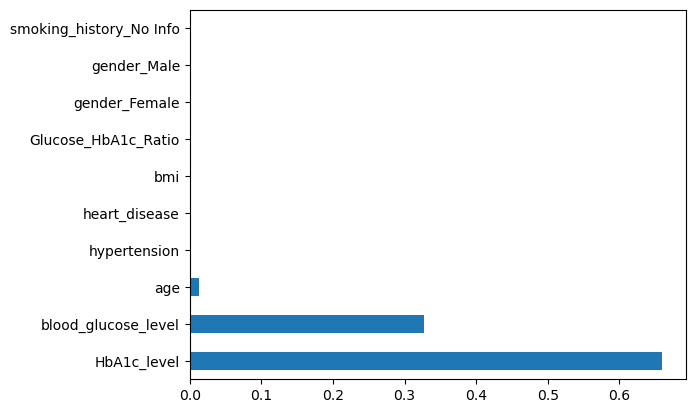

In [132]:
from sklearn import tree
clf=tree.DecisionTreeClassifier(max_depth=3,criterion='gini')
DTree=clf.fit(X_train,y_train)
prediction=DTree.predict(X_test)
from sklearn import metrics
print(metrics.classification_report(y_test,prediction))
print(metrics.confusion_matrix(y_test,prediction))
F1_Score=metrics.f1_score(y_test,prediction,average='weighted')
print('Sample Data Accuaracy:',np.round((F1_Score),2)*100,'%')
feature_importances=pd.Series(DTree.feature_importances_,index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
from sklearn.model_selection import cross_val_score
AccuracyValues=cross_val_score(DTree,X,y,cv=5,scoring='f1_weighted')
print(AccuracyValues)
train_acc = DTree.score(X_train, y_train)
test_acc = DTree.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc) 
print('Final Accuracy of the Model:',np.round(np.mean(AccuracyValues),2)*100,'%')

## Random Forest Classifier

RandomForestClassifier(n_estimators=1000, oob_score=True)
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17548
           1       0.94      0.69      0.80      1678

    accuracy                           0.97     19226
   macro avg       0.95      0.84      0.89     19226
weighted avg       0.97      0.97      0.97     19226

[[17470    78]
 [  515  1163]]


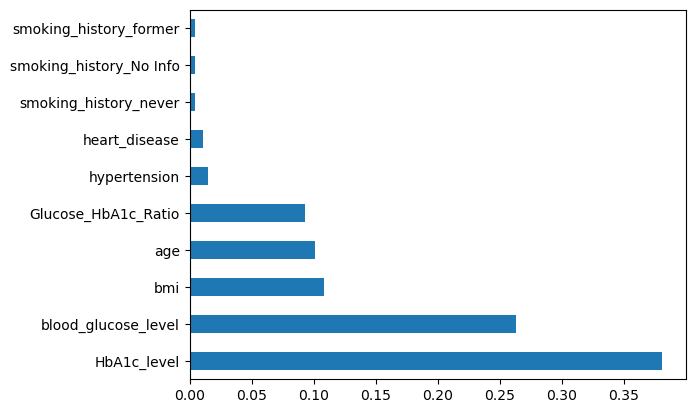

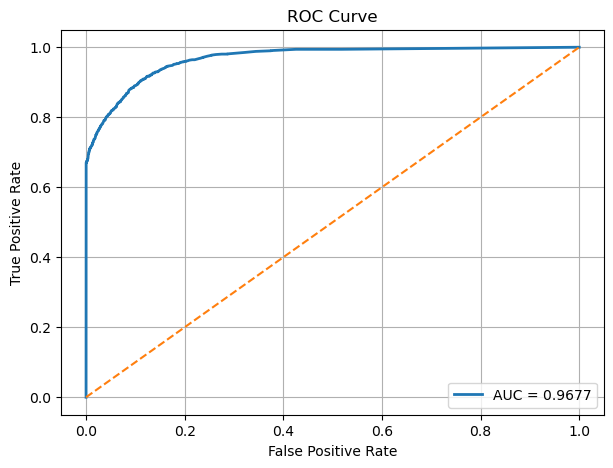

OOB Score: 97.0 %
OOB Error: 3.0 %
ROC-AUC Score: 0.9677
Train Accuracy: 0.9992197862214247
Test Accuracy : 0.9691563507749922
Final Accuracy of the Model: 96.7 %


In [134]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=1000,criterion='gini', oob_score=True)
print(clf)
 
#Creating the model on Training Data
RF=clf.fit(X_train,y_train)
prediction=RF.predict(X_test)

#Measuring accuracy on Testing Data
from sklearn import metrics
print(metrics.classification_report(y_test, prediction))
print(metrics.confusion_matrix(y_test, prediction)) 
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(RF.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults['cardio']=y_test
TestingDataResults['Prediction']=prediction
TestingDataResults.head()


from sklearn.metrics import roc_curve, roc_auc_score

y_prob = RF.predict_proba(X_test)[:, 1]



auc = roc_auc_score(y_test, y_prob)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, linewidth=2, label=f'AUC = {auc:.4f}')
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


OOBScore = RF.oob_score_

print("OOB Score:", round(OOBScore,2)*100,'%')

OOBError = 1 - OOBScore

print("OOB Error:", round(OOBError,2)*100,'%')


auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc, 4))
train_acc = RF.score(X_train, y_train)
test_acc = RF.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc) 
print('Final Accuracy of the Model:',round(metrics.f1_score(y_test, prediction,average='weighted'),4)*100,"%")

In [30]:
#!pip install xgboost

In [31]:
#import sys
#!{sys.executable} -m pip install xgboost

In [32]:
#from xgboost import XGBClassifier

#print("XGBoost installed successfully!")

In [33]:
#import sys
#print(sys.executable) 

In [34]:
#import sys
#!{sys.executable} -m pip show xgboost

In [35]:
#import sys
#print(sys.executable)

#!{sys.executable} -m pip list

## XGBoost Classifier

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, num_parallel_tree=None, ...)
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98     17548
         1.0       0.97      0.69      0.81      1678

    accuracy                           0.97     19226
   macro avg       0.9

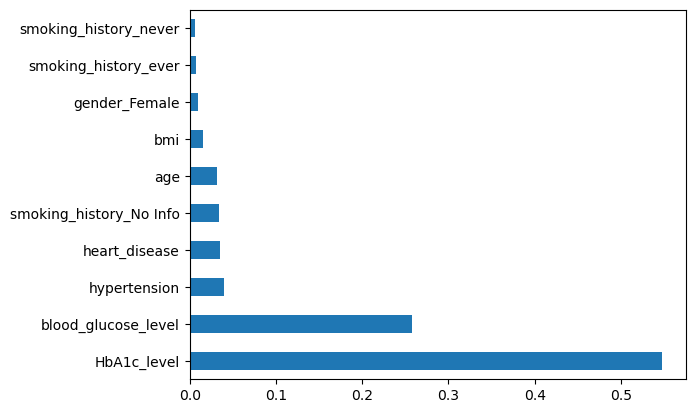

In [89]:
###### Xgboost Classification in Python #######
import pandas as pd 
from xgboost import XGBClassifier
clf=XGBClassifier(max_depth=4, learning_rate=0.1, n_estimators=400, objective='binary:logistic', booster='gbtree')
 
#Printing all the parameters of XGBoost
print(clf)
 
#Creating the model on Training Data                                                                                                         

 

XGB=clf.fit(X_train,y_train)
prediction=XGB.predict(X_test)
 
#Measuring accuracy on Testing Data
from sklearn import metrics
print(metrics.classification_report(y_test, prediction))

print(metrics.confusion_matrix(y_test, prediction))
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(XGB.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh') 
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults['TargetColumn']=y_test
TestingDataResults['Prediction']=prediction   
TestingDataResults.head()
print('Final Accuracy of the Model:',round(metrics.f1_score(y_test, prediction,average='weighted'),4)*100,"%")

## Ada Boost Classifier

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3),
                   learning_rate=0.05, n_estimators=100)
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98     17548
         1.0       1.00      0.67      0.80      1678

    accuracy                           0.97     19226
   macro avg       0.98      0.83      0.89     19226
weighted avg       0.97      0.97      0.97     19226

[[17548     0]
 [  556  1122]]


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,TargetColumn,Prediction
11335,65.00,0,0,28.25,5.0,100,0,1,0,0,0,0,0,1,0,0.0,0.0
56000,40.00,0,0,27.32,5.7,155,1,0,0,1,0,0,0,0,0,0.0,0.0
15246,68.00,0,0,34.18,4.8,159,0,1,0,0,1,0,0,0,0,0.0,0.0
88102,1.72,0,0,17.19,3.5,158,1,0,0,1,0,0,0,0,0,0.0,0.0
12543,46.00,0,0,26.15,6.6,159,0,1,0,0,0,0,1,0,0,0.0,0.0


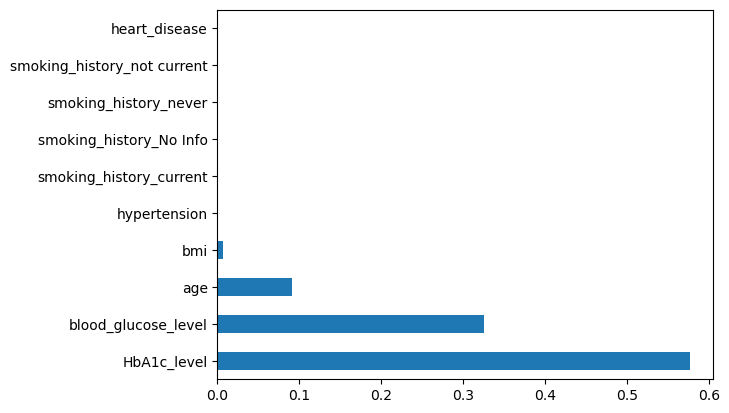

In [93]:
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
 
#Choosing Decision Tree with 1 level as the weak learner
DTC=DecisionTreeClassifier(max_depth=3)
clf = AdaBoostClassifier(n_estimators=100, estimator=DTC ,learning_rate=0.05)
 
#Printing all the parameters of Adaboost
print(clf)
 
#Creating the model on Training Data
AB=clf.fit(X_train,y_train)
prediction=AB.predict(X_test)
 
#Measuring accuracy on Testing Data
from sklearn import metrics
print(metrics.classification_report(y_test, prediction))
print(metrics.confusion_matrix(y_test, prediction))
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(AB.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults['TargetColumn']=y_test
TestingDataResults['Prediction']=prediction
TestingDataResults.head()

In [38]:
import sys
print(sys.executable)

C:\ProgramData\anaconda3\python.exe


In [39]:
import sys
!{sys.executable} -m pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [40]:
import sys
print(sys.executable)
!where python
!pip show xgboost

C:\ProgramData\anaconda3\python.exe
C:\ProgramData\anaconda3\python.exe
C:\Users\abrau\AppData\Local\Microsoft\WindowsApps\python.exe
Name: xgboost
Version: 3.2.0
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: C:\Users\abrau\AppData\Roaming\Python\Python313\site-packages
Requires: numpy, scipy
Required-by: 


# Selected XGBoost Classification Model for Deployment

## Deploying on Sample Production Data

In [91]:
DataForMLDiabetesPredictionData_Numeric.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,diabetes
0,80.0,0,1,25.19,6.6,140,1,0,0,0,0,0,0,1,0,0.0
1,54.0,0,0,27.32,6.6,80,1,0,0,1,0,0,0,0,0,0.0
2,28.0,0,0,27.32,5.7,158,0,1,0,0,0,0,0,1,0,0.0
3,36.0,0,0,23.45,5.0,155,1,0,0,0,1,0,0,0,0,0.0
4,76.0,1,1,20.14,4.8,155,0,1,0,0,1,0,0,0,0,0.0


In [94]:
NewData = pd.DataFrame(data=[
[45,0,0,24.8,5.4,98,1,0,0,0,0,0,0,1,0],
[62,1,0,31.6,7.1,182,0,1,0,0,0,0,1,0,0],
[28,0,0,22.4,5.2,90,1,0,0,0,0,0,0,1,0],
[51,0,1,29.7,6.8,170,0,1,0,0,1,0,0,0,0],
[39,0,0,26.5,5.8,115,1,0,0,1,0,0,0,0,0],
[70,1,1,33.9,8.2,240,0,1,0,0,0,0,1,0,0],
[34,0,0,23.1,5.0,88,0,1,0,0,0,0,0,1,0],
[57,1,0,30.2,6.9,165,1,0,0,0,0,1,0,0,0],
[41,0,0,27.6,5.7,110,0,1,0,0,0,0,0,0,1],
[65,1,1,34.5,7.8,210,1,0,0,0,0,0,1,0,0],
[22,0,0,21.3,4.9,82,0,1,0,0,0,0,0,1,0],
[49,0,0,28.9,6.1,132,1,0,0,1,0,0,0,0,0],
[74,1,1,35.8,8.5,255,0,1,0,0,0,0,1,0,0],
[30,0,0,24.5,5.3,94,1,0,0,0,1,0,0,0,0],
[53,1,0,29.8,6.7,175,0,1,0,0,0,1,0,0,0],
[37,0,0,25.9,5.5,102,1,0,0,0,0,0,0,1,0],
[68,1,1,32.7,7.6,198,0,1,0,1,0,0,0,0,0],
[46,0,0,27.2,5.9,118,1,0,0,0,0,0,1,0,0],
[59,1,0,31.1,7.0,185,0,1,0,0,0,0,0,0,1],
[26,0,0,22.7,5.1,89,1,0,0,0,0,0,0,1,0]
], columns=predictors)


In [95]:
newX=NewData.values

In [96]:
XGB.predict(newX)

array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0])

In [97]:
def GenerateSurvialPred(inpData):
    newX=inpData.values
    # Making sure the new data is also Normalized using the same normalization PredictorScalerFit
    pred=XGB.predict(newX)
    inpData['Prediction']=pred
    return(inpData)

In [98]:
GenerateSurvialPred(inpData=NewData)

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,Prediction
0,45,0,0,24.8,5.4,98,1,0,0,0,0,0,0,1,0,0
1,62,1,0,31.6,7.1,182,0,1,0,0,0,0,1,0,0,1
2,28,0,0,22.4,5.2,90,1,0,0,0,0,0,0,1,0,0
3,51,0,1,29.7,6.8,170,0,1,0,0,1,0,0,0,0,1
4,39,0,0,26.5,5.8,115,1,0,0,1,0,0,0,0,0,0
5,70,1,1,33.9,8.2,240,0,1,0,0,0,0,1,0,0,1
6,34,0,0,23.1,5.0,88,0,1,0,0,0,0,0,1,0,0
7,57,1,0,30.2,6.9,165,1,0,0,0,0,1,0,0,0,1
8,41,0,0,27.6,5.7,110,0,1,0,0,0,0,0,0,1,0
9,65,1,1,34.5,7.8,210,1,0,0,0,0,0,1,0,0,1
